In [5]:
from ultralytics import YOLO

ImportError: cannot import name 'deprecated' from 'typing_extensions' (/usr/local/share/pynq-venv/lib/python3.10/site-packages/typing_extensions.py)

In [ ]:
import torch
import cv2
import sys
from ultralytics.data.augment import LetterBox
from ultralytics.utils.plotting import Annotator, colors
from ultralytics.utils import ops
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image, clear_output

In [ ]:
model = YOLO("yolov8n.pt") # モデルの設定
cap = cv2.VideoCapture(0) # カメラからデバイス情報を取得
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640) # 表示画像の幅を設定
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480) # 表示画像の高さを設定
cap.set(cv2.CAP_PROP_FPS, 60) # 表示画像のfpsを設定

In [ ]:
# 画像を出力する関数
def imshow(frame):
   # 文字を描画（FPS)
    cv2.putText(frame, "FPS : " + str(fps) , (10, 25), cv2.FONT_HERSHEY_COMPLEX, 1, (255, 0, 0), 2, cv2.LINE_AA)
    _, buf = cv2.imencode(".jpg", frame) # エンコード方法にJPEGを指定
    display(Image(data=buf.tobytes()))
    clear_output(wait=True)

In [4]:
# 前処理を行う関数
def preprocess(frame, size=160):
        frame = LetterBox(size, True)(image=frame) # レターボックス化
        frame = frame.transpose((2, 0, 1))[::-1] # HWCからCHW、BGRからRGBへの変換
        frame = np.ascontiguousarray(frame) # 配列が連続したメモリに位置するよう配置し直す
        frame = torch.from_numpy(frame) # numpy配列からPytorch Tensor への変換
        frame = frame.float() # 画像をintからfloatに変換
        frame /= 255 # 画像のRGB値を255で割ることで0から1への値に正規化
        return frame.unsqueeze(0)

In [5]:
# 後処理を行う関数
def postprocess(preds, frame, orig_frame):
    
    # Non Maximum Suppression
    preds = ops.non_max_suppression(preds, 0.25, 0.8, agnostic=False, max_det=100)
    
    # 推論結果をBoundingBoxに変換
    for _, pred in enumerate(preds):
        shape = orig_frame.shape
        pred[:, :4] = ops.scale_boxes(frame.shape[2:], pred[:, :4], shape).round()

    return preds

In [6]:
# ラベル付きBoundingBoxを描画する関数
def drow_bbox(pred, names, annotator):
    for *bbox, conf, cls in reversed(pred):
        label =  f'{names[int(cls)]} {conf:.2f}'
        annotator.box_label(bbox, label, color=colors(cls, True))

In [7]:
#OpenCVのタイマーの準備
timer = cv2.TickMeter()
timer.start()

In [8]:
#各変数の初期値設定(FPS)
count = 0
max_count =30
fps = 0

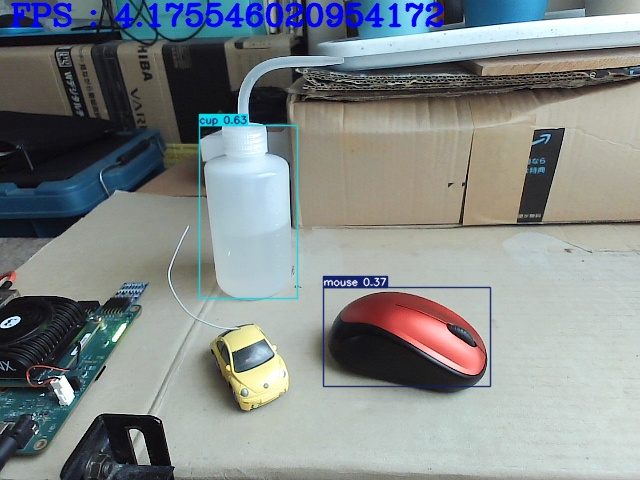

In [ ]:
# メイン処理
while True:
    try:
        ret, frame = cap.read() # デバイス情報から読み込み情報と画像を取得
        
        # 画像が読み込めていない場合は処理を打ち切る
        if not ret:
            break

        #Max_Countの回数になったら、その枚数を取得するのにかかった時間を求めてFPSを算出
        if count == max_count:
            timer.stop()
            fps = max_count / timer.getTimeSec()
            #print("FPS(Actual):" , '{:11.02f}'.format(fps))        
            #リセットと再スタート
            timer.reset()
            count = 0
            timer.start() 
            
        orig_frame = deepcopy(frame)
        annotator = Annotator(orig_frame, line_width=1, example=str(model.model.names)) # ラベルの情報を取得
        frame = preprocess(frame) # 前処理
        preds = model.model(frame, augment=False) # 推論
        preds = postprocess(preds, frame, orig_frame) # 後処理
        drow_bbox(preds[0], model.model.names, annotator) # 入力画像にラベル付きBoundingBoxを描画
        imshow(orig_frame) # 処理された画像を出力
        count += 1
        
    # 停止ボタン■で停止
    except KeyboardInterrupt:
        break

In [ ]:
cap.release()